In [1]:
import pandas as pd

# read_csv can read in just about any plain-text tabular data
data = pd.read_csv('/home/jovyan/nh26_td_gamb_diff_FC_best/wide_diff_all_data.csv', sep=',')

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (691, 107)


,subjectID,age_group,strata,Gender,DDisc_AUC_40K,Release,Acquisition,Age,3T_Full_MR_Compl,7T_Full_MR_Compl,...,Occipital_dki_mk,Orbital_dki_mk,PostParietal_dki_mk,SLF_L_dki_mk,SLF_R_dki_mk,SupFrontal_dki_mk,SupParietal_dki_mk,Temporal_dki_mk,UNC_L_dki_mk,UNC_R_dki_mk
0,100206,26-30,26-30_M,M,0.050000,S900,Q11,26-30,True,False,...,1.101557,1.084557,1.053842,1.107496,1.110725,1.112234,1.026142,1.056521,0.995955,0.988601
1,100307,26-30,26-30_F,F,0.311459,Q1,Q01,26-30,True,False,...,1.006925,1.045562,0.987310,1.008259,1.024426,0.984244,0.928578,0.976830,0.895127,0.915798
2,100610,26-30,26-30_M,M,0.868750,S900,Q08,26-30,True,True,...,0.996652,1.105037,1.005991,1.009783,1.057179,1.042984,0.986284,1.009254,0.956977,0.977282
3,101006,31-35,31-35_F,F,0.783073,S500,Q06,31-35,True,False,...,0.931849,1.074894,0.951102,1.011284,1.040509,1.017018,0.981339,0.962131,0.965962,1.004965
4,101107,22-25,22-25_M,M,0.584375,S500,Q06,22-25,True,False,...,0.971370,1.107099,0.975676,0.999982,1.025620,1.027364,0.963823,0.960659,0.917482,0.953508


In [4]:
import pandas as pd
import numpy as np

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
data = pd.read_csv(
    "/home/jovyan/nh26_td_gamb_diff_FC_best/wide_diff_all_data.csv"
)

print("Dataset shape:", data.shape)

# ------------------------------------------------------------------
# Select all DKI features (96 features)
# ------------------------------------------------------------------
X = data.filter(like="dki")
y = data["DDisc_AUC_40K"]

print("Feature matrix shape:", X.shape)

# ------------------------------------------------------------------
# Elastic Net model
# ------------------------------------------------------------------
enet = Pipeline([
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(
        alpha=.1,
        l1_ratio=0.5,
        random_state=0
    ))
])

# ------------------------------------------------------------------
# 5-fold cross-validation
# ------------------------------------------------------------------
r2_cv = cross_val_score(
    enet,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross-validated R² values:")
print(r2_cv)
print(f"\nMean R²: {r2_cv.mean():.4f}")

# ------------------------------------------------------------------
# Fit final model on all data
# ------------------------------------------------------------------
enet.fit(X, y)

# Extract fitted ElasticNet model
fitted_enet = enet.named_steps["elasticnet"]

# ------------------------------------------------------------------
# Feature summary
# ------------------------------------------------------------------
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": fitted_enet.coef_,
    "Abs_Coefficient": np.abs(fitted_enet.coef_)
})

feature_summary = feature_summary.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print("\nTop 20 Features:")
print(feature_summary.head(20))

# ------------------------------------------------------------------
# Features retained by Elastic Net
# ------------------------------------------------------------------
selected_features = feature_summary[
    feature_summary["Coefficient"] != 0
]

print(
    f"\nSelected {len(selected_features)} of "
    f"{len(feature_summary)} features"
)

print(selected_features)

# ------------------------------------------------------------------
# Save results
# ------------------------------------------------------------------
feature_summary.to_csv(
    "elasticnet_feature_summary.csv",
    index=False
)

print("\nFeature summary saved to:")
print("elasticnet_feature_summary.csv")

Dataset shape: (691, 107)
Feature matrix shape: (691, 96)

Cross-validated R² values:
[-0.00137043 -0.04603752 -0.00488661 -0.00056944 -0.00611777]

Mean R²: -0.0118

Top 20 Features:
                 Feature  Coefficient  Abs_Coefficient
80          CST_R_dki_mk         -0.0              0.0
81          IFO_L_dki_mk         -0.0              0.0
82          IFO_R_dki_mk         -0.0              0.0
83          ILF_L_dki_mk         -0.0              0.0
84          ILF_R_dki_mk         -0.0              0.0
85          Motor_dki_mk         -0.0              0.0
86      Occipital_dki_mk         -0.0              0.0
87        Orbital_dki_mk          0.0              0.0
8          CST_R_dki_awf          0.0              0.0
9          IFO_L_dki_awf         -0.0              0.0
10         IFO_R_dki_awf         -0.0              0.0
11         ILF_L_dki_awf         -0.0              0.0
12         ILF_R_dki_awf         -0.0              0.0
13         Motor_dki_awf         -0.0         

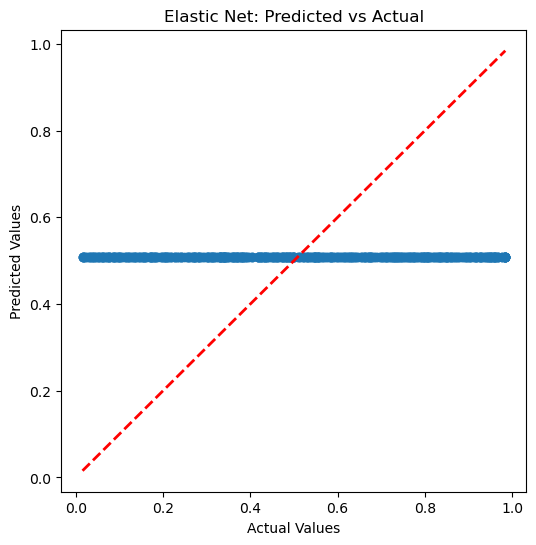

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

# Fit model
enet = ElasticNet(alpha=.10, l1_ratio=0.5, random_state=0)
enet.fit(X, y)

# Predictions
y_pred = enet.predict(X)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    lw=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Elastic Net: Predicted vs Actual")
plt.show()